# Behind the scenes: Day One
### -> How the data was downloaded

In [2]:
# imports required for this notebook

import requests
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from workshop_utils import RAW_DIR, PROCESSED_DIR

### Berkeley Earth Surface Temperature (BEST) Dataset

In [ ]:
url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"
out_path = RAW_DIR / "berkeley_earth_global_temp.txt"

r = requests.get(url)

# uncomment to download:
#out_path.write_text(r.text)

416532

In [ ]:
# Define the columns based on Berkeley Earth's documentation
columns = [
    "Year", "Month", "Anomaly_Monthly", "Unc_Monthly",
    "Anomaly_Annual", "Unc_Annual", "Anomaly_FiveYear", "Unc_FiveYear",
    "Anomaly_TenYear", "Unc_TenYear", "Anomaly_TwentyYear", "Unc_TwentyYear"
]

df = pd.read_csv(
    RAW_DIR / "BEST" / "berkeley_earth_global_temp.txt",
    comment="%",              # Ignores all the header text lines starting with %
    sep=r"\s+",              # Handles variable whitespace spacing between numbers
    header=None,             # The file doesn't have a standard row header
    names=columns,           # Assigns our clean column names
    nrows=2100               # Optional: Reads only up to the first data block
)

# Compute yearly mean anomaly and save
best_yearly = df.groupby("Year")["Anomaly_Monthly"].mean().reset_index()
best_yearly.columns = ["Year", "Anomaly"]
#best_yearly.to_csv(PROCESSED_DIR / "best_yearly.csv", index=False)
print(f"Saved best_yearly.csv ({len(best_yearly)} rows)")

best_yearly.head()

Saved best_yearly.csv (175 rows)


,Year,Anomaly
0,1850,-0.435667
1,1851,-0.320750
2,1852,-0.292250
3,1853,-0.294500
4,1854,-0.283333


### NASA GISTEMP Surface Temperature Dataset

In [6]:
gistemp_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
gistemp_raw = RAW_DIR / "NASA" / "gistemp_global.csv"

# uncomment to download:
#gistemp_raw.write_text(requests.get(gistemp_url).text)

In [ ]:
gistemp = pd.read_csv(gistemp_raw, skiprows=1)

# melt monthly columns into long format
month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
gistemp_long = gistemp.melt(
    id_vars=["Year"],
    value_vars=month_cols,
    var_name="month",
    value_name="Anomaly"
)
gistemp_long["Anomaly"] = pd.to_numeric(gistemp_long["Anomaly"], errors="coerce")
gistemp_yearly = gistemp_long.groupby("Year")["Anomaly"].mean().reset_index()

#gistemp_yearly.to_csv(PROCESSED_DIR / "gistemp_yearly.csv", index=False)
print(f"Saved gistemp_yearly.csv ({len(gistemp_yearly)} rows)")

gistemp_yearly.head()

Saved gistemp_yearly.csv (147 rows)


,Year,Anomaly
0,1880,-0.176667
1,1881,-0.090833
2,1882,-0.110833
3,1883,-0.173333
4,1884,-0.284167


### Philippines temperature and precipitation
Here, we use ERA5 data to specifically zoom into the Philippines and Bacolod. Below, ERA5 reanalysis data is downloaded for the entire region year by year, with a temperature recording 4 times per day (00, 06, 12, and 18 UTC), and daily precipitation sums.

In [ ]:
# actually, let me go ahead and download from Copernicus API
# bounding box for the Philippines (roughly):
N_lat, S_lat, W_lon, E_lon = 21.25, 4.5, 114, 126.75

from workshop_utils.download import download_era5_copernicus

# download in single year increments
for year in range(1940, 2025):
    download_era5_copernicus(
        variable=["2m_temperature"],
        year=[str(year)],
        month=[f"{i:02d}" for i in range(1, 13)],
        day=[f"{i:02d}" for i in range(1, 32)],
        time=[f"{i:02d}:00" for i in range(0, 24, 6)],
        area=[N_lat, W_lon, S_lat, E_lon],
        output_path=RAW_DIR / "ERA5" / "2m_temperature" / f"t2m_philippines_{year}.nc",
    )

### ERA5 climatology for the Philippines (1991–2020)
Compute the 30-year mean temperature and annual mean precipitation from the downloaded raw files and save as NetCDF for use in the student notebooks.

In [ ]:
# Compute 1991–2020 climatology means and save as NetCDF
t2m_clim_files = sorted(RAW_DIR.glob("ERA5/2m_temperature/t2m_philippines_*.nc"))
t2m_clim_files = [f for f in t2m_clim_files if 1991 <= int(f.stem.split("_")[-1]) <= 2020]

ds_t2m_clim = xr.open_mfdataset(t2m_clim_files, combine="by_coords", drop_variables=["number"])
t2m_mean = (ds_t2m_clim["t2m"].mean("valid_time") - 273.15).compute()

tp_clim_files = sorted(RAW_DIR.glob("ERA5/precipitation/tp_philippines_*.nc"))
tp_clim_files = [f for f in tp_clim_files if 1991 <= int(f.stem.split("_")[-1]) <= 2020]

ds_tp_clim = xr.open_mfdataset(tp_clim_files, combine="by_coords", drop_variables=["number"])
tp_mean_annual = (ds_tp_clim["tp"].mean("valid_time") * 1000 * 365).compute()

# uncomment to save:
#t2m_mean.to_netcdf(PROCESSED_DIR / "t2m_clim_mean.nc")
#tp_mean_annual.to_netcdf(PROCESSED_DIR / "tp_clim_annual_mean.nc")
print("Saved t2m_clim_mean.nc and tp_clim_annual_mean.nc")

Saved t2m_clim_mean.nc and tp_clim_annual_mean.nc


### Bacolod ERA5 time series (1940–2024)
Extract the Bacolod grid point from the full ERA5 record and compute the yearly temperature series and monthly climatologies (1991–2020) used in Part III.

In [ ]:
BACOLOD_LAT = 10.68
BACOLOD_LON = 122.95

all_t2m_files = sorted(RAW_DIR.glob("ERA5/2m_temperature/t2m_philippines_*.nc"))
ds_t2m_all = xr.open_mfdataset(all_t2m_files, combine="by_coords", drop_variables=["number"])
t2m_bacolod = (ds_t2m_all["t2m"]
               .sel(latitude=BACOLOD_LAT, longitude=BACOLOD_LON, method="nearest")
               - 273.15)

t2m_yearly  = t2m_bacolod.groupby("valid_time.year").mean().compute()
t2m_monthly = (t2m_bacolod
               .sel(valid_time=slice("1991", "2020"))
               .groupby("valid_time.month").mean().compute())

all_tp_files = sorted(RAW_DIR.glob("ERA5/precipitation/tp_philippines_*.nc"))
ds_tp_all = xr.open_mfdataset(all_tp_files, combine="by_coords", drop_variables=["number"])
tp_bacolod = (ds_tp_all["tp"]
              .sel(latitude=BACOLOD_LAT, longitude=BACOLOD_LON, method="nearest")
              * 1000)  # m/day → mm/day
tp_monthly = (tp_bacolod
              .sel(valid_time=slice("1991", "2020"))
              .resample(valid_time="MS").sum()           # sum daily values → monthly total (mm/month)
              .groupby("valid_time.month").mean()        # average each calendar month across 1991–2020
              .compute())

# uncomment to save:
# t2m_yearly.to_netcdf(PROCESSED_DIR / "t2m_bacolod_yearly.nc")
# t2m_monthly.to_netcdf(PROCESSED_DIR / "t2m_bacolod_monthly.nc")
#tp_monthly.to_netcdf(PROCESSED_DIR / "tp_bacolod_monthly.nc")
print("Saved t2m_bacolod_yearly.nc, t2m_bacolod_monthly.nc, tp_bacolod_monthly.nc")

Saved t2m_bacolod_yearly.nc, t2m_bacolod_monthly.nc, tp_bacolod_monthly.nc


### CHIRPS Precipitation Dataset

Might not use this, actually. Let's keep it in for now.

In [ ]:
url = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_monthly/netcdf/chirps-v2.0.monthly.nc"
ds = xr.open_dataset(url)
# ...

### Mauna Loa CO2 record -- NOAA Global Monitoring Laboratory

In [ ]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
co2_raw = RAW_DIR / "mauna_loa_co2.csv"

# uncomment to download:
#co2_raw.write_text(requests.get(url).text)

38600

In [ ]:
# Process CO₂: filter missing values, save monthly and yearly CSVs
co2_raw     = pd.read_csv(RAW_DIR / "NOAA" / "mauna_loa_co2.csv", comment="#")
co2_monthly = co2_raw[co2_raw["average"] > 0].copy()
#co2_monthly.to_csv(PROCESSED_DIR / "co2_monthly.csv", index=False)
print(f"Saved co2_monthly.csv ({len(co2_monthly)} rows)")

co2_yearly = co2_monthly.groupby("year")["average"].mean().reset_index()
#co2_yearly.to_csv(PROCESSED_DIR / "co2_yearly.csv", index=False)
print(f"Saved co2_yearly.csv ({len(co2_yearly)} rows)")

Saved co2_monthly.csv (819 rows)
Saved co2_yearly.csv (69 rows)


### ENSO (Niño3.4 Index) -- NOAA Physical Sciences Laboratory via KNMI

In [11]:
# KNMI (Dutch Weather Agency) hosts a "Climate Explorer" tool that allows you do download various climate indices, including ENSO (El Niño Southern Oscillation) data. Here's how you can download and process the ENSO data to get a yearly average of the NINO3.4 index:

url = "https://climexp.knmi.nl/data/iersst_nino3.4a_rel.nc"
ds = xr.open_dataset(url,
                     engine="h5netcdf",
                     decode_times=False)    # time unit is months since 1854-01-15
# fix time axis (currently float32, has to be months since 1854-01-15)
ds["time"] = pd.to_datetime("1854-01-15") + pd.to_timedelta(ds["time"].values, unit="m")

# uncomment to download:
# #ds.to_netcdf(RAW_DIR / 'NOAA' / 'nino.nc')

In [ ]:
# Process ENSO: fix time axis, compute yearly mean, save CSV
nino_ds = xr.open_dataset(RAW_DIR / "NOAA" / "nino.nc", decode_times=False)
nino_ds["time"] = (
    pd.date_range(start="1854-01-01", periods=nino_ds.sizes["time"], freq="MS")
    + pd.Timedelta(days=14)
)
nino = nino_ds["Nino3.4r"]

nino_yearly = (
    pd.DataFrame({"date": nino_ds["time"].values, "enso": nino.values})
    .assign(Year=lambda df: pd.DatetimeIndex(df["date"]).year)
    .groupby("Year")["enso"].mean()
    .reset_index()
)
#nino_yearly.to_csv(PROCESSED_DIR / "enso_yearly.csv", index=False)
print(f"Saved enso_yearly.csv ({len(nino_yearly)} rows)")

Saved enso_yearly.csv (173 rows)


### Aerosol Optical Depth (AOD, proxy for volcanic activity) -- NASA GISS
Should appear as large spikes:
- 1963  Agung
- 1982  El Chichón
- 1991  Pinatubo

In [16]:
url = "https://data.giss.nasa.gov/modelforce/strataer/data/tau_reff_Sato-Lacis.nc"

# Download the file
r = requests.get(url)
out_path = RAW_DIR / "NASA" / "sato_lacis_aod.nc"

# uncomment to download:
#out_path.write_bytes(r.content)

1222680

In [ ]:
# Process AOD: sum over altitude levels, average over latitude, save as CSV
aod_ds = xr.open_dataset(RAW_DIR / "NASA" / "sato_lacis_aod.nc")
aod_global = aod_ds["tau_lvl"].sum("level").mean("lat")
time_dates = pd.to_datetime(aod_ds["month"].values)
aod_years  = time_dates.year + (time_dates.month - 1) / 12

aod_df = pd.DataFrame({"year": aod_years, "aod": aod_global.values})
#aod_df.to_csv(PROCESSED_DIR / "aod_global.csv", index=False)
print(f"Saved aod_global.csv ({len(aod_df)} rows)")

Saved aod_global.csv (2076 rows)


### Total Solar Irradiance (TSI) -- NOAA

In [ ]:
for year in range(2025, 1874, -1):
    if year == 2025:
        creation = "20260305"
    elif year == 2024:
        creation = "20250221"
    else:
        creation = "20240831"

    url = (
        f"https://www.ncei.noaa.gov/data/total-solar-irradiance/access/monthly/"
        f"tsi_v03r00_monthly_s{year}01_e{year}12_c{creation}.nc"
    )
    out_path = RAW_DIR / "NOAA" / f"tsi_{year}.nc"
    if out_path.exists():
        print(f"skip {year}")
        continue
    out_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            out_path.write_bytes(r.content)
            print(f"saved {out_path.name}")
        else:
            print(f"failed {year}: {r.status_code}")
    except Exception as e:
        print(f"error {year}: {e}")

In [ ]:
# Process TSI: concatenate all yearly netCDF files → monthly and yearly CSVs
tsi_files = sorted(RAW_DIR.glob("NOAA/tsi_*.nc"))

tsi_list = []
for f in tsi_files:
    ds = xr.open_dataset(f)
    tsi_list.append(ds[["TSI"]].load())
    ds.close()

tsi = xr.concat(tsi_list, dim="time")

# Monthly
tsi_monthly = pd.DataFrame({"time": tsi["time"].values, "TSI": tsi["TSI"].values})
#tsi_monthly.to_csv(PROCESSED_DIR / "tsi_monthly.csv", index=False)
print(f"Saved tsi_monthly.csv ({len(tsi_monthly)} rows)")

# Yearly
tsi_yr = tsi["TSI"].resample(time="YE").mean()
tsi_yearly = pd.DataFrame({"Year": tsi_yr.time.dt.year.values, "TSI": tsi_yr.values})
#tsi_yearly.to_csv(PROCESSED_DIR / "tsi_yearly.csv", index=False)
print(f"Saved tsi_yearly.csv ({len(tsi_yearly)} rows)")

Saved tsi_monthly.csv (1812 rows)
Saved tsi_yearly.csv (151 rows)


### EPICA Dome C Ice Core

In [ ]:
url = "https://doi.pangaea.de/10.1594/PANGAEA.683655?format=textfile"
out_path = RAW_DIR / "EPICA" / "epica_dome_c.txt"
out_path.parent.mkdir(parents=True, exist_ok=True)

r = requests.get(url, timeout=30)
r.raise_for_status()

#out_path.write_text(r.text, encoding="utf-8")

194365

In [ ]:
# Process EPICA: parse the raw text file, save clean CSV
epica_raw = pd.read_csv(
    RAW_DIR / "EPICA" / "epica_dome_c.txt",
    sep="\t",
    skiprows=20,
    na_values=[""],
)
epica_raw.columns = ["depth_m", "age_ka", "dD_permil", "delta_t_c", "sample_id"]
epica = epica_raw.dropna(subset=["age_ka", "delta_t_c"])[["age_ka", "delta_t_c"]].copy()
#epica.to_csv(PROCESSED_DIR / "epica.csv", index=False)
print(f"Saved epica.csv ({len(epica)} rows)")

Saved epica.csv (5788 rows)


In [ ]:
url = "https://www.ncei.noaa.gov/pub/data/paleo/icecore/antarctica/epica_domec/vostok-edc3-co2-2008-noaa.txt"

# download to RAW / NOAA / vostok-edc3-co2-2008-noaa.txt
out_path = RAW_DIR / "NOAA" / "vostok-edc3-co2-2008-noaa.txt"
r = requests.get(url)

# uncomment to download:
#out_path.write_text(r.text)

26610

In [ ]:
# Process Vostok CO₂: parse raw text, save clean CSV (age in ka before present)
vostok_raw = pd.read_csv(
    RAW_DIR / "NOAA" / "vostok-edc3-co2-2008-noaa.txt",
    sep="\t",
    skiprows=482,
)
vostok_raw.columns = ["depth_m", "gas_age_bp", "co2_ppm"]
vostok = (
    vostok_raw
    .dropna(subset=["gas_age_bp", "co2_ppm"])
    .assign(
        gas_age_bp=lambda df: pd.to_numeric(df["gas_age_bp"], errors="coerce"),
        co2_ppm=lambda df: pd.to_numeric(df["co2_ppm"], errors="coerce"),
    )
    .dropna(subset=["gas_age_bp", "co2_ppm"])
    .sort_values("gas_age_bp")
    .assign(age_ka=lambda df: df["gas_age_bp"] / 1000)
    [["age_ka", "co2_ppm"]]
)
#vostok.to_csv(PROCESSED_DIR / "vostok_co2.csv", index=False)
print(f"Saved vostok_co2.csv ({len(vostok)} rows)")

Saved vostok_co2.csv (372 rows)


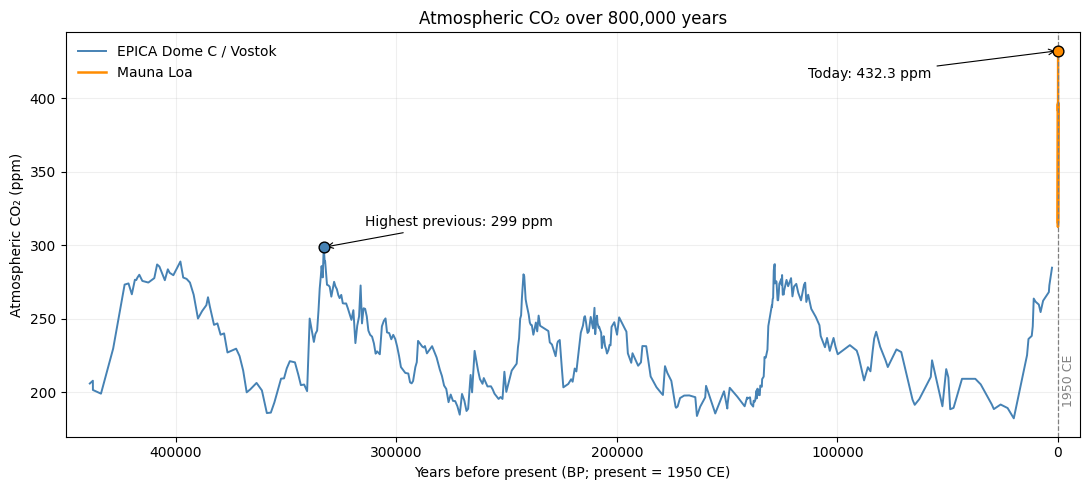

In [15]:
# Vostok CO₂ + Mauna Loa extension — 800,000-year CO₂ context
mauna_loa = pd.read_csv(PROCESSED_DIR / "co2_monthly.csv")
mauna_loa["bp"] = 1950 - mauna_loa["decimal date"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(vostok["age_ka"] * 1000, vostok["co2_ppm"],
        color="steelblue", linewidth=1.4, label="EPICA Dome C / Vostok")
ax.plot(mauna_loa["bp"], mauna_loa["average"],
        color="darkorange", linewidth=1.8, label="Mauna Loa")

ax.axvline(0, color="gray", linewidth=0.9, linestyle="--")
ax.text(-2000, 190, "1950 CE", color="gray", fontsize=9, rotation=90, va="bottom")

vostok_max = vostok.loc[vostok["co2_ppm"].idxmax()]
mauna_max  = mauna_loa.loc[mauna_loa["average"].idxmax()]

ax.scatter(vostok_max["age_ka"] * 1000, vostok_max["co2_ppm"],
           s=60, color="steelblue", edgecolor="black", zorder=5)
ax.scatter(mauna_max["bp"], mauna_max["average"],
           s=60, color="darkorange", edgecolor="black", zorder=5)

ax.annotate(f'Highest previous: {vostok_max["co2_ppm"]:.0f} ppm',
            xy=(vostok_max["age_ka"] * 1000, vostok_max["co2_ppm"]),
            xytext=(30, 15), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.annotate(f'Today: {mauna_max["average"]:.1f} ppm',
            xy=(mauna_max["bp"], mauna_max["average"]),
            xytext=(-180, -20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=0.8))

ax.set_xlim(450000, -10000)
ax.set_xlabel("Years before present (BP; present = 1950 CE)")
ax.set_ylabel("Atmospheric CO₂ (ppm)")
ax.set_title("Atmospheric CO₂ over 800,000 years")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Köppen-Geiger climate maps from Beck et al.

In [ ]:
import zipfile

In [7]:
url = "https://doi.org/10.6084/m9.figshare.21789074"

# List all files in the figshare article so we can see what is available
FIGSHARE_ID = 21789074
resp = requests.get(f'https://api.figshare.com/v2/articles/{FIGSHARE_ID}/files')
resp.raise_for_status()
all_files = resp.json()

print(f'Found {len(all_files)} files:\n')
for f in all_files:
    print(f'  {f["name"]:<70s}  {f["size"]/1e6:7.1f} MB')

Found 5 files:

  koppen_geiger_tif.zip                                                     130.6 MB
  koppen_geiger_nc.zip                                                      755.3 MB
  climate_data_0p1.zip                                                     1478.9 MB
  climate_data_0p5.zip                                                       94.1 MB
  climate_data_1p0.zip                                                       28.8 MB


In [ ]:
# Download koppen_geiger_nc.zip and climate_data_0p1.zip
target_files = {"koppen_geiger_nc.zip", "climate_data_0p1.zip"}
beck_dir = RAW_DIR / "Beck"
beck_dir.mkdir(parents=True, exist_ok=True)

for f in all_files:
    if f["name"] not in target_files:
        continue
    out_path = beck_dir / f["name"]
    if out_path.exists():
        print(f"skip {f['name']}")
        continue
    print(f"downloading {f['name']} ({f['size']/1e6:.0f} MB) ...", end="", flush=True)
    r = requests.get(f["download_url"], stream=True)
    r.raise_for_status()
    with open(out_path, "wb") as fp:
        for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
            fp.write(chunk)
    print(" done")

In [ ]:
# Extract both zips and list NC files found inside
beck_dir = RAW_DIR / "Beck"

for zip_name in ["koppen_geiger_nc.zip", "climate_data_0p1.zip"]:
    extract_dir = beck_dir / zip_name.replace(".zip", "")
    if extract_dir.exists() and any(extract_dir.rglob("*.nc")):
        print(f"already extracted: {zip_name}")
        continue
    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"extracting {zip_name} ...", end="", flush=True)
    with zipfile.ZipFile(beck_dir / zip_name) as zf:
        zf.extractall(extract_dir)
    print(" done")

print("\nKöppen-Geiger NC files:")
for p in sorted((beck_dir / "koppen_geiger_nc").rglob("*.nc")):
    print(f"  {p.name}")

In [ ]:
import shutil, stat, os

beck_dir = RAW_DIR / "Beck"
keep_periods = {"1901_1930", "1991_2020", "2071_2099"}

def rmtree(path):
    """shutil.rmtree with read-only fix for Windows/OneDrive."""
    def _fix_readonly(func, p, _):
        os.chmod(p, stat.S_IWRITE)
        func(p)
    shutil.rmtree(path, onerror=_fix_readonly)

# --- Remove unwanted period folders from both sub-datasets ---
for sub in ["koppen_geiger_nc", "climate_data_0p1"]:
    for d in list((beck_dir / sub).iterdir()):
        if d.is_dir() and d.name not in keep_periods:
            rmtree(d)
            print(f"removed {sub}/{d.name}/")

# --- koppen_geiger_nc: keep only koppen_geiger_0p1.nc in historical periods ---
for period in ["1901_1930", "1991_2020"]:
    for f in (beck_dir / "koppen_geiger_nc" / period).iterdir():
        if f.name != "koppen_geiger_0p1.nc":
            os.chmod(f, stat.S_IWRITE)
            f.unlink()
            print(f"removed koppen_geiger_nc/{period}/{f.name}")

# --- 2071_2099: keep only ssp460/ in both sub-datasets ---
for sub in ["koppen_geiger_nc", "climate_data_0p1"]:
    future_dir = beck_dir / sub / "2071_2099"
    for d in list(future_dir.iterdir()):
        if d.name != "ssp460":
            rmtree(d)
            print(f"removed {sub}/2071_2099/{d.name}/")
    # koppen_geiger_nc: also drop non-0p1 files inside ssp460
    if sub == "koppen_geiger_nc":
        for f in (future_dir / "ssp460").iterdir():
            if f.name != "koppen_geiger_0p1.nc":
                os.chmod(f, stat.S_IWRITE)
                f.unlink()
                print(f"removed {sub}/2071_2099/ssp460/{f.name}")

# --- Crop to Philippines and save to PROCESSED_DIR ---
PH_LAT = (4.5, 21.5)
PH_LON = (113.5, 127.0)

def crop_philippines(ds):
    lat_name = "latitude" if "latitude" in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"
    lat = ds[lat_name].values
    if lat[0] > lat[-1]:   # decreasing (90 → -90)
        return ds.sel({lat_name: slice(PH_LAT[1], PH_LAT[0]),
                       lon_name: slice(PH_LON[0], PH_LON[1])})
    else:                   # increasing (-90 → 90)
        return ds.sel({lat_name: slice(PH_LAT[0], PH_LAT[1]),
                       lon_name: slice(PH_LON[0], PH_LON[1])})

clim = beck_dir / "climate_data_0p1"

targets = [
    # KG classification maps
    (beck_dir / "koppen_geiger_nc/1991_2020/koppen_geiger_0p1.nc",        "kg_philippines_present.nc"),
    (beck_dir / "koppen_geiger_nc/2071_2099/ssp460/koppen_geiger_0p1.nc", "kg_philippines_future_ssp460.nc"),
    # Climate data — ensemble mean and std for each kept period
    (clim / "1901_1930/ensemble_mean_0p1.nc",        "climate_philippines_1901_1930_mean.nc"),
    (clim / "1901_1930/ensemble_std_0p1.nc",         "climate_philippines_1901_1930_std.nc"),
    (clim / "1991_2020/ensemble_mean_0p1.nc",        "climate_philippines_1991_2020_mean.nc"),
    (clim / "1991_2020/ensemble_std_0p1.nc",         "climate_philippines_1991_2020_std.nc"),
    (clim / "2071_2099/ssp460/ensemble_mean_0p1.nc", "climate_philippines_2071_2099_ssp460_mean.nc"),
    (clim / "2071_2099/ssp460/ensemble_std_0p1.nc",  "climate_philippines_2071_2099_ssp460_std.nc"),
]

for src, out_name in targets:
    ds_ph = crop_philippines(xr.open_dataset(src))
    #ds_ph.to_netcdf(PROCESSED_DIR / out_name)
    print(f"{src.parent.name}/{src.name}  →  {out_name}  {dict(ds_ph.sizes)}")

1991_2020/koppen_geiger_0p1.nc  →  kg_philippines_present.nc  {'lat': 170, 'lon': 135}
ssp460/koppen_geiger_0p1.nc  →  kg_philippines_future_ssp460.nc  {'lat': 170, 'lon': 135}
1901_1930/ensemble_mean_0p1.nc  →  climate_philippines_1901_1930_mean.nc  {'time': 12, 'lat': 170, 'lon': 135}
1901_1930/ensemble_std_0p1.nc  →  climate_philippines_1901_1930_std.nc  {'time': 12, 'lat': 170, 'lon': 135}
1991_2020/ensemble_mean_0p1.nc  →  climate_philippines_1991_2020_mean.nc  {'time': 12, 'lat': 170, 'lon': 135}
1991_2020/ensemble_std_0p1.nc  →  climate_philippines_1991_2020_std.nc  {'time': 12, 'lat': 170, 'lon': 135}
ssp460/ensemble_mean_0p1.nc  →  climate_philippines_2071_2099_ssp460_mean.nc  {'time': 12, 'lat': 170, 'lon': 135}
ssp460/ensemble_std_0p1.nc  →  climate_philippines_2071_2099_ssp460_std.nc  {'time': 12, 'lat': 170, 'lon': 135}
